In [29]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns 
pio.renderers.default = 'notebook' # force plotly to render inside the notebook

NYC People in Homless shelters + Evictions
1. How are eviction trends related to homelessness in New York City?
2. Do increases in evictions correspond with increases in the number of people staying in NYC homeless shelters?
3. Which boroughs experience the highest levels of eviction and homelessness.
4. Eviction by Borough chart(graph)
5. Shelter by Borough chart (graph)
6. Homeless population over time chart (graph)
7. Compare eviction vs population(graph)

In [30]:
df_evictions = pd.read_csv("Evictions_20260715.csv")
df_shelter_people = pd.read_csv("DHS_Daily_Report_20260715.csv")

In [31]:
df_evictions

,Court Index Number,Docket Number,Eviction Address,Eviction Apartment Number,Executed Date,Marshal First Name,Marshal Last Name,Residential/Commercial,BOROUGH,Eviction Postcode,Ejectment,Eviction/Legal Possession,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA
0,325688/23,26140,2565 MARION AVENUE APT 2C,2C,09/17/2025,Robert,Renzulli,Residential,BRONX,10458,Not an Ejectment,Possession,40.862931,-73.892217,7.0,15.0,39901.0,2016602.0,2.032860e+09,Bedford Park-Fordham North
1,57364/16*,166775,2776 JEROME AVENUE,1E,03/16/2017,Alfred,Locascio,Residential,BRONX,10468,Not an Ejectment,Possession,40.869722,-73.895327,7.0,14.0,40303.0,2017499.0,2.033180e+09,Van Cortlandt Village
2,330886/22A,123564,1563 METROPOLITAN AVENUE,4A,08/13/2025,Darlene,Barone,Residential,BRONX,10462,Not an Ejectment,Possession,40.839696,-73.858059,9.0,18.0,21001.0,2096772.0,2.039448e+09,Parkchester
3,318146/24B,144754,637 EAST 224TH STR EET,4F,09/11/2025,Justin,Grossman,Residential,BRONX,10466,Not an Ejectment,Possession,40.887742,-73.862843,12.0,12.0,394.0,2121925.0,2.048260e+09,Williamsbridge-Olinville
4,B304354/25,139836,445 GERARD AVENUE,W818,01/21/2026,Darlene,Barone,Residential,BRONX,10451,Not an Ejectment,Possession,40.817398,-73.929872,1.0,8.0,63.0,2001095.0,2.023510e+09,West Concourse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130236,63313/18,61548,432 MILFORD STREET,2,06/04/2018,Howard,Schain,Residential,BROOKLYN,11208,Not an Ejectment,Possession,40.668334,-73.875262,5.0,42.0,1118.0,3393717.0,3.044560e+09,East New York
130237,76186/16A,65622,162 WEST 141ST ST,1,03/08/2018,Justin,Grossman,Residential,MANHATTAN,10030,Not an Ejectment,Possession,40.818617,-73.939809,10.0,9.0,230.0,1060077.0,1.020090e+09,Central Harlem North-Polo Grounds
130238,304096/23,16376,730 ROCKAWAY AVENUE APT 5A,5A,10/25/2024,Robert,Renzulli,Residential,BROOKLYN,11212,Not an Ejectment,Possession,40.661951,-73.908776,16.0,42.0,916.0,3397844.0,3.035890e+09,Brownsville
130239,310140/23,6969,507 EAST 161 STREET,13D,01/30/2024,David,Smith,Residential,BRONX,10451,Not an Ejectment,Possession,40.823066,-73.910004,3.0,17.0,141.0,2116648.0,2.023660e+09,Morrisania-Melrose


DATA WRANGLING OF EVICTIONS

In [91]:
df_evictions['Residential/Commercial'].unique()
df_evictions['Residential/Commercial'].replace(['R','Residential' 'C','Commercil'])

0         Residential
1         Residential
2         Residential
3         Residential
4         Residential
             ...     
130236    Residential
130237    Residential
130238    Residential
130239    Residential
130240    Residential
Name: Residential/Commercial, Length: 130241, dtype: object

In [95]:
df_evi_resi = df_evictions[df_evictions['Residential/Commercial'] == "Residential"]

In [93]:
df_evictions['Residential/Commercial'].isnull().sum()
df_evictions['Residential/Commercial']

0

In [17]:
df_evictions.isnull().sum()

Court Index Number               0
Docket Number                    0
Eviction Address                 0
Eviction Apartment Number    18849
Executed Date                    0
Marshal First Name               0
Marshal Last Name                0
Residential/Commercial           0
BOROUGH                          0
Eviction Postcode                0
Ejectment                      437
Eviction/Legal Possession        0
Latitude                     11582
Longitude                    11582
Community Board              11582
Council District             11582
Census Tract                 11582
BIN                          12052
BBL                          12052
NTA                          11582
dtype: int64

In [32]:
#changing date from obj to datetype
df_evictions['Executed Date'] = pd.to_datetime(df_evictions['Executed Date'], format='%m/%d/%Y')

In [33]:
#exctrating month and year to see evictions based on year and month 
df_evictions['Year'] = (df_evictions['Executed Date'].dt.year)
df_evictions['Month'] = (df_evictions['Executed Date'].dt.month)

In [34]:
#to make joining easier 
df_evictions['Month_Year'] = (df_evictions['Executed Date'].dt.to_period('M'))

In [35]:
df_evictions.dtypes

Court Index Number                   object
Docket Number                         int64
Eviction Address                     object
Eviction Apartment Number            object
Executed Date                datetime64[ns]
Marshal First Name                   object
Marshal Last Name                    object
Residential/Commercial               object
BOROUGH                              object
Eviction Postcode                     int64
Ejectment                            object
Eviction/Legal Possession            object
Latitude                            float64
Longitude                           float64
Community Board                     float64
Council District                    float64
Census Tract                        float64
BIN                                 float64
BBL                                 float64
NTA                                  object
Year                                  int32
Month                                 int32
Month_Year                      

In [132]:
df_evictions['Ejectment'].isnull().sum()

437

In [125]:
df_shelter_people

,Date of Census,Total Adults in Shelter,Total Children in Shelter,Total Individuals in Shelter,Single Adult Men in Shelter,Single Adult Women in Shelter,Total Single Adults in Shelter,Families with Children in Shelter,Adults in Families with Children in Shelter,Children in Families with Children in Shelter,Total Individuals in Families with Children in Shelter,Adult Families in Shelter,Individuals in Adult Families in Shelter,Year,Month,Month_Year
0,2021-03-01,35195,16746,51941,13936,4543,18479,9593,12662,16746,29408,1920,4054,2021,3,2021-03
1,2021-03-02,35202,16746,51948,13962,4526,18488,9590,12658,16746,29404,1922,4056,2021,3,2021-03
2,2021-03-03,35108,16720,51828,13931,4503,18434,9579,12638,16720,29358,1913,4036,2021,3,2021-03
3,2021-03-04,35176,16720,51896,13989,4526,18515,9578,12626,16720,29346,1911,4035,2021,3,2021-03
4,2021-03-05,35103,16766,51869,13939,4485,18424,9598,12647,16766,29413,1908,4032,2021,3,2021-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1957,2026-07-10,54718,28339,83057,18199,7359,25558,16404,24148,28339,52487,2312,5012,2026,7,2026-07
1958,2026-07-11,54773,28363,83136,18219,7355,25574,16429,24170,28363,52533,2319,5029,2026,7,2026-07
1959,2026-07-12,54758,28289,83047,18262,7372,25634,16394,24107,28289,52396,2315,5017,2026,7,2026-07
1960,2026-07-13,54781,28289,83070,18309,7359,25668,16386,24096,28289,52385,2314,5017,2026,7,2026-07


DATA WRANGLING OF SHELTER POPULATION 

In [36]:
df_shelter_people.dtypes

Date of Census                                             object
Total Adults in Shelter                                     int64
Total Children in Shelter                                   int64
Total Individuals in Shelter                                int64
Single Adult Men in Shelter                                 int64
Single Adult Women in Shelter                               int64
Total Single Adults in Shelter                              int64
Families with Children in Shelter                           int64
Adults in Families with Children in Shelter                 int64
Children in Families with Children in Shelter               int64
Total Individuals in Families with Children in Shelter      int64
Adult Families in Shelter                                   int64
Individuals in Adult Families in Shelter                    int64
dtype: object

In [37]:
#changing date from obj to datetype
df_shelter_people['Date of Census'] = pd.to_datetime(df_shelter_people['Date of Census'], format='%m/%d/%Y')

In [38]:
df_shelter_people.isnull().sum()

Date of Census                                             0
Total Adults in Shelter                                    0
Total Children in Shelter                                  0
Total Individuals in Shelter                               0
Single Adult Men in Shelter                                0
Single Adult Women in Shelter                              0
Total Single Adults in Shelter                             0
Families with Children in Shelter                          0
Adults in Families with Children in Shelter                0
Children in Families with Children in Shelter              0
Total Individuals in Families with Children in Shelter     0
Adult Families in Shelter                                  0
Individuals in Adult Families in Shelter                   0
dtype: int64

In [59]:
df_shelter_people['Year'] = (df_shelter_people['Date of Census'].dt.year)
df_shelter_people['Month'] = (df_shelter_people['Date of Census'].dt.month)

In [61]:
df_shelter_people['Month_Year'] = (df_shelter_people['Date of Census'].dt.to_period('M'))

In [62]:
print(df_shelter_people["Month_Year"].min())
print(df_shelter_people["Month_Year"].max())

2021-03
2026-07


In [63]:
print(df_evictions["Month_Year"].min())
print(df_evictions["Month_Year"].max())

2017-01
2026-07


Summarizing Each Data Set by Month Year THrough
Aggergated 

In [96]:
evictions_monthly = (
    df_evi_resi.groupby("Month_Year").size().reset_index(name="Residential Evictions"))

In [80]:
shelter_monthly = (
    df_shelter_people.groupby("Month_Year")["Total Individuals in Shelter"].mean().reset_index(name="Average Shelter Population"))

In [81]:
evictions_monthly.head()

,Month_Year,Evictions
0,2017-01,2237
1,2017-02,1695
2,2017-03,2040
3,2017-04,1860
4,2017-05,2080


In [77]:
shelter_monthly.head()

,Month_Year,Average Shelter Population
0,2021-03,51399.806452
1,2021-04,50021.666667
2,2021-05,48677.903226
3,2021-06,47669.366667
4,2021-07,45395.645161


In [97]:
#merge inner to keep the months consistent 
df= pd.merge(
shelter_monthly,evictions_monthly, on="Month_Year", how="inner")

In [69]:
print(sorted(df_evictions["BOROUGH"].unique()))

['BRONX', 'BROOKLYN', 'KINGS', 'MANHATTAN', 'NEW YORK', 'QUEENS', 'RICHMOND', 'STATEN ISLAND']


In [70]:
df_evictions["BOROUGH"] = df_evictions["BOROUGH"].replace({"KINGS": "BROOKLYN", "NEW YORK": "MANHATTAN","RICHMOND": "STATEN ISLAND"})

In [71]:
df_evictions['BOROUGH'].unique()

array(['BRONX', 'QUEENS', 'MANHATTAN', 'BROOKLYN', 'STATEN ISLAND'],
      dtype=object)

In [83]:
df

,Month_Year,Average Shelter Population,Evictions
0,2021-03,51399.806452,1
1,2021-04,50021.666667,3
2,2021-05,48677.903226,6
3,2021-06,47669.366667,9
4,2021-07,45395.645161,52
...,...,...,...
60,2026-03,84907.935484,1843
61,2026-04,83766.300000,1573
62,2026-05,82905.161290,1375
63,2026-06,82615.066667,1676


In [48]:
#want it so that both graphs are from the same month and year
df_evictions2021 = df_evictions[df_evictions["Executed Date"] >= '2021/03/01']

df_shelter_people2021 = df_shelter_people[df_shelter_people["Date of Census"] >= '2021/03/01']

/var/folders/hc/m39stmk92x16gy5pp2jx30br0000gn/T/ipykernel_52400/4074605671.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


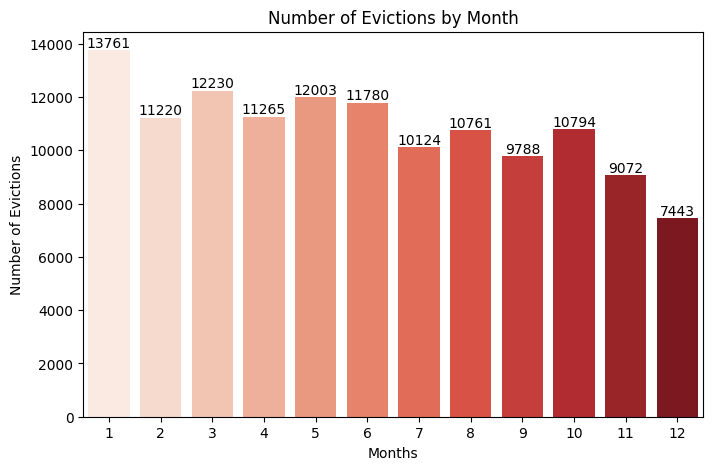

In [50]:
plt.figure(figsize=(8,5))

month_order = ['1', '2', '3', '4', '5', '6', 
               '7', '8', '9', '10', '11', '12']

ax = sns.countplot(
    data=df_evictions,
    x="Month",
    order=month_order,
    palette="Reds",
    legend=False
    
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Evictions by Month")
plt.xlabel("Months")
plt.ylabel("Number of Evictions")

plt.show()

In [ ]:
df_evictions["BOROUGH"] = df_evictions["BOROUGH"].str.replace("BBROOKLYN","BROOKLYN")


/var/folders/hc/m39stmk92x16gy5pp2jx30br0000gn/T/ipykernel_52400/2697403376.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


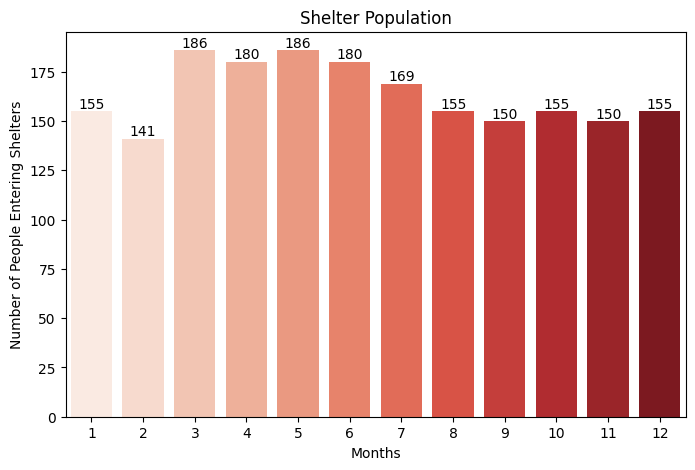

In [46]:
#number of people going into shelters
plt.figure(figsize=(8,5))

month_order = ['1', '2', '3', '4', '5', '6', 
               '7', '8', '9', '10', '11', '12']

ax = sns.countplot(
    data=df_shelter_people,
    x="Month",
    order=month_order,
    palette="Reds"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Shelter Population")
plt.xlabel("Months")
plt.ylabel("Number of People Entering Shelters")

plt.show()



In [98]:
evictions_monthly = (df_evi_resi.groupby('Month_Year').size().reset_index(name="Residential Evictions"))

In [99]:
shelter_monthly = (df_shelter_people.groupby('Month_Year')['Total Individuals in Shelter'].mean().reset_index(name="Average Shelter Population"))

In [100]:
df_comb = pd.merge(shelter_monthly,evictions_monthly,on='Month_Year',how='inner')

In [109]:
df_comb.dtypes
df_comb["Month_Year"] = df_comb['Month_Year'].dt.to_timestamp()

In [121]:
correlation = df_comb["Residential Evictions"].corr(df_comb['Average Shelter Population'])
correlation

0.9076265683826176

In [123]:
correlation_matrix = df_comb[["Residential Evictions","Average Shelter Population"]].corr()
correlation_matrix

,Residential Evictions,Average Shelter Population
Residential Evictions,1.000000,0.907627
Average Shelter Population,0.907627,1.000000


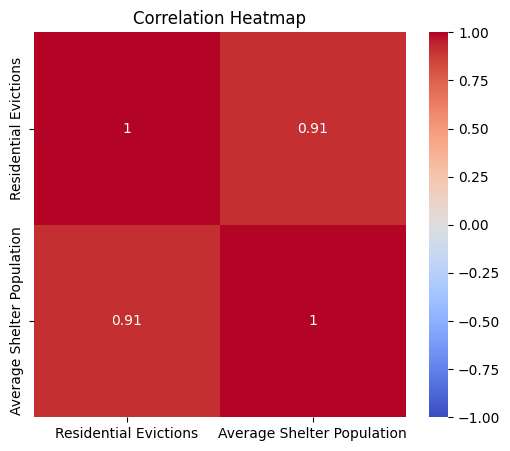

In [124]:
plt.figure(figsize=(6,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1)
plt.title('Correlation Heatmap')

plt.show()
    

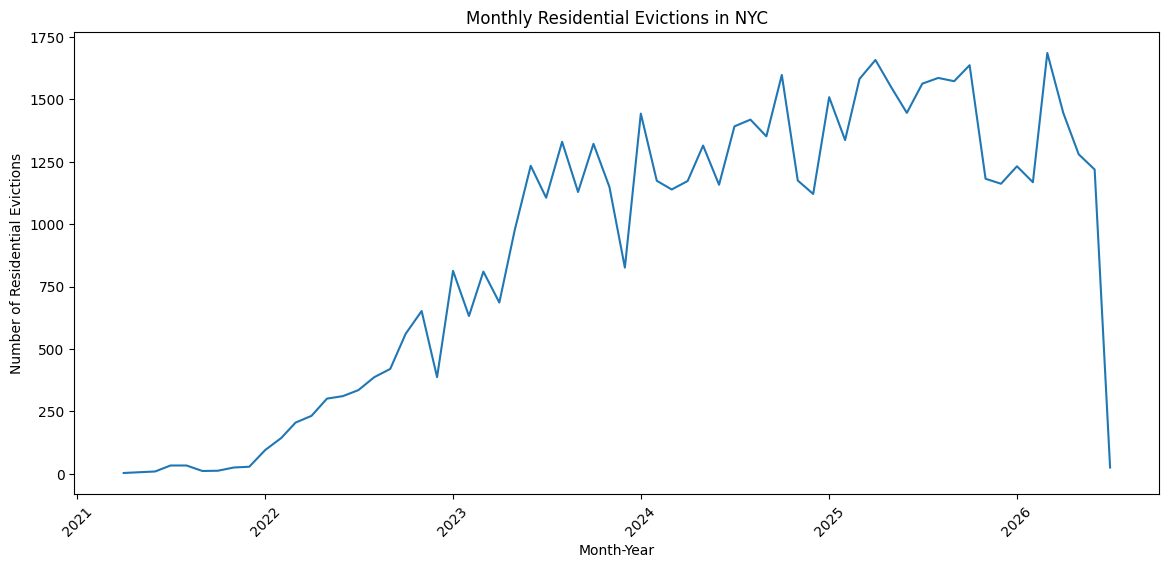

In [110]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data = df_comb,
    x= 'Month_Year',
    y= 'Residential Evictions',
    )

plt.title('Monthly Residential Evictions in NYC')
plt.xlabel('Month-Year'),
plt.ylabel('Number of Residential Evictions')
plt.xticks(rotation=45)

plt.show()

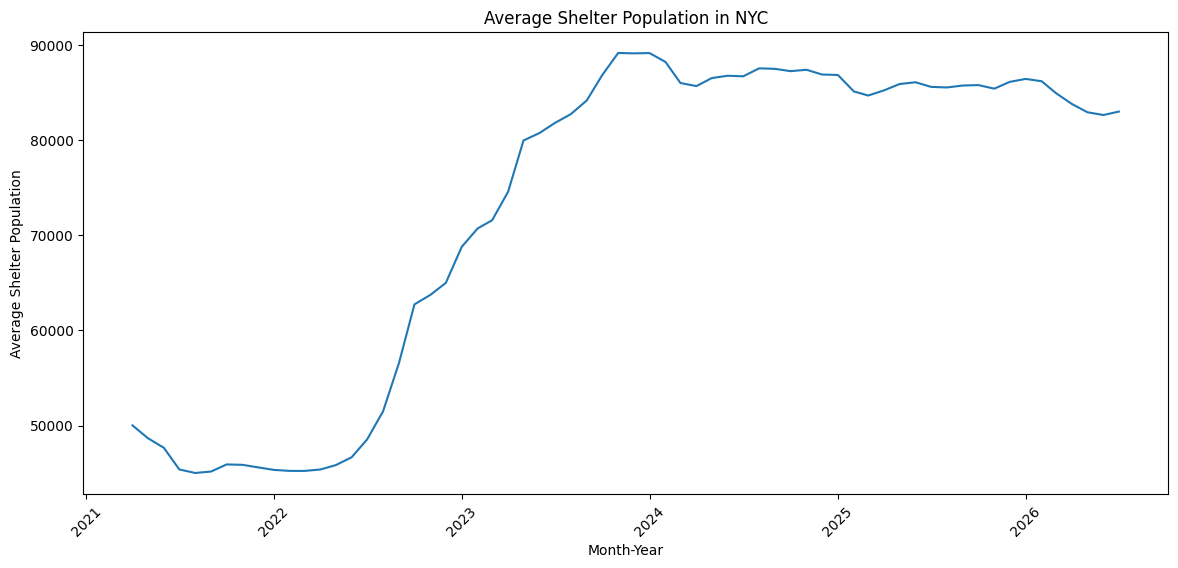

In [111]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data = df_comb,
    x= 'Month_Year',
    y= 'Average Shelter Population',
    )

plt.title('Average Shelter Population in NYC')
plt.xlabel('Month-Year'),
plt.ylabel('Average Shelter Population')
plt.xticks(rotation=45)

plt.show()

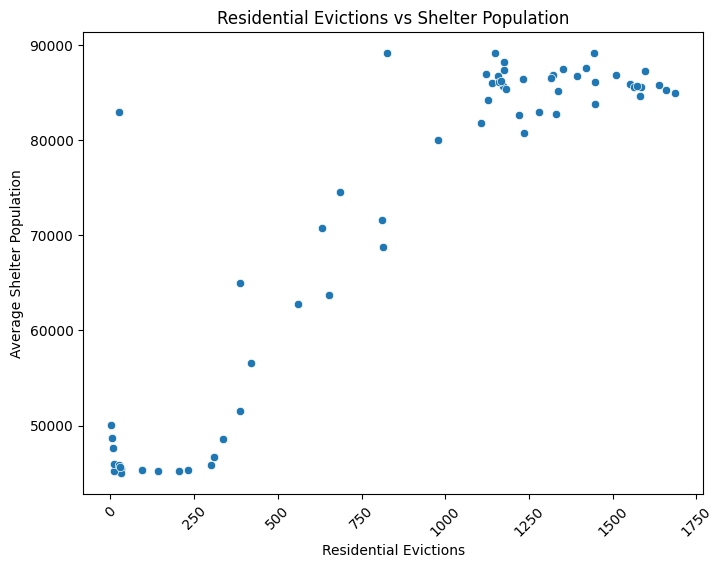

In [112]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data = df_comb,
    x= 'Residential Evictions',
    y= 'Average Shelter Population',
    )

plt.title('Residential Evictions vs Shelter Population')
plt.xlabel('Residential Evictions'),
plt.ylabel('Average Shelter Population')
plt.xticks(rotation=45)

plt.show()